# LAB WORKSHOP: Ekstraksi Fitur Citra Tradisional (Hand-Crafted Features)
**Mata Kuliah:** Pengolahan Citra Digital  
**Target Kompetensi:** CPMK 041 & CPMK 081 (Ekstraksi Fitur Invarian, Analisis Geometri, dan Tekstur)

## Agenda Praktikum:
1. **Fitur Bentuk Lanjut:** Implementasi Freeman Chain Code (Absolute & Differential) dari Nol.
2. **Fitur Bentuk Geometris:** Polgonal Approximation dengan Variasi Epsilon.
3. **Fitur Tekstur Mikroskopis:** Distribusi Spasial Local Binary Pattern (LBP).
4. **Fitur Tekstur Statistik:** Matriks Kekooperatifan Keabuan (GLCM).
5. **Fitur Titik Lokal:** Harris Corner Detection & Analisis Invariansi.

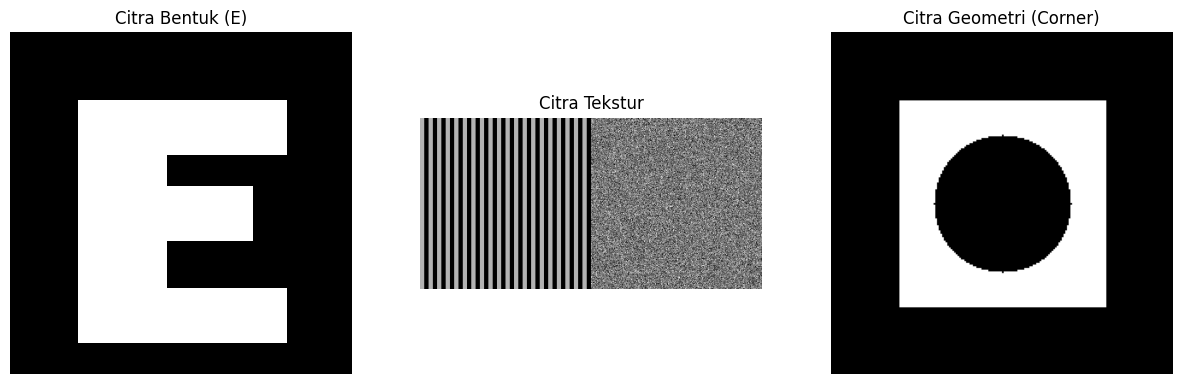

In [26]:
# ==========================================
# CELL SETUP & GENERATOR DATA SINTETIS
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

def generate_lab_dataset():
    # 1. Gambar Digital 'Huruf E' Sederhana untuk Chain Code & Poligon
    img_e = np.zeros((100, 100), dtype=np.uint8)
    # Batas luar huruf E
    pts = np.array([[20,20], [80,20], [80,35], [45,35], [45,45], [70,45],
                    [70,60], [45,60], [45,75], [80,75], [80,90], [20,90]], np.int32)
    cv2.fillPoly(img_e, [pts], 255)

    # 2. Gambar Tekstur Kontras (Kiri: Halus/Uniform, Kanan: Kasar/Grit)
    img_tex = np.zeros((200, 400), dtype=np.uint8)
    # Kiri: Pola Garis Halus
    for i in range(0, 200, 10):
        img_tex[:, i:i+5] = 180
    # Kanan: Pola Gaussian Noise Kasar
    noise = np.random.normal(120, 40, (200, 200))
    img_tex[:, 200:] = np.clip(noise, 0, 255).astype(np.uint8)

    # 3. Gambar Objek Geometris untuk Harris Corner
    img_geo = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(img_geo, (40, 40), (160, 160), 255, -1)
    cv2.circle(img_geo, (100, 100), 40, 0, -1) # Lubang di tengah

    return img_e, img_tex, img_geo

img_e, img_tex, img_geo = generate_lab_dataset()

# Tampilkan Dataset awal
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_e, cmap='gray'); axes[0].set_title("Citra Bentuk (E)")
axes[1].imshow(img_tex, cmap='gray'); axes[1].set_title("Citra Tekstur")
axes[2].imshow(img_geo, cmap='gray'); axes[2].set_title("Citra Geometri (Corner)")
for ax in axes: ax.axis('off')
plt.show()

## BAGIAN 1: Freeman Chain Code (8-Connected)

Freeman Chain Code merepresentasikan batas objek biner menggunakan urutan arah (0 sampai 7).
Arah didefinisikan berdasarkan perubahan koordinat $(\Delta x, \Delta y)$ dari satu piksel batas ke piksel berikutnya.

**Arah Rujukan (Standard 8-Connected):**
* `0`: Kanan $(1, 0)$
* `1`: Kanan-Atas $(1, -1)$
* `2`: Atas $(0, -1)$
* `3`: Kiri-Atas $(-1, -1)$
* `4`: Kiri $(-1, 0)$
* `5`: Kiri-Bawah $(-1, 1)$
* `6`: Bawah $(0, 1)$
* `7`: Kanan-Bawah $(1, 1)$

*Catatan: Nilai Y negatif berarti bergerak ke atas pada koordinat citra.*

**Differential Chain Code:** Diturunkan untuk mencapai sifat *Rotation Invariant*. Rumusnya:
$$D_i = (C_i - C_{i-1}) \pmod 8$$

In [27]:
def extract_freeman_chain_code(binary_image):
    # Cari kontur tanpa aproksimasi (wajib CHAIN_APPROX_NONE untuk melacak per piksel)
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return [], []

    # Ambil kontur pertama (terluar)
    contour = contours[0]

    # Mapping dari perubahan posisi (dx, dy) ke kode arah Freeman
    freeman_lookup = {
        (1, 0): 0,   # Kanan
        (1, -1): 1,  # Kanan-Atas
        (0, -1): 2,  # Atas
        (-1, -1): 3, # Kiri-Atas
        (-1, 0): 4,  # Kiri
        (-1, 1): 5,  # Kiri-Bawah
        (0, 1): 6,   # Bawah
        (1, 1): 7    # Kanan-Bawah
    }

    absolute_chain = []

    # Iterasi menyusuri setiap piksel di sepanjang garis kontur
    for i in range(len(contour)):
        p_current = contour[i][0]
        # Jika sudah di ujung kontur, hubungkan kembali ke piksel pertama
        p_next = contour[(i + 1) % len(contour)][0]

        dx = p_next[0] - p_current[0]
        dy = p_next[1] - p_current[1]

        # Normalisasi langkah menjadi -1, 0, atau 1
        step = (np.sign(dx), np.sign(dy))

        if step in freeman_lookup:
            absolute_chain.append(freeman_lookup[step])

    # Hitung Differential Chain Code (Selisih arah)
    differential_chain = []
    for i in range(len(absolute_chain)):
        c_current = absolute_chain[i]
        c_prev = absolute_chain[i - 1] # i-1 pada indeks 0 akan otomatis mengambil indeks terakhir
        diff = (c_current - c_prev) % 8
        differential_chain.append(diff)

    return absolute_chain, differential_chain

# Eksekusi Fungsi
abs_code, diff_code = extract_freeman_chain_code(img_e)

print(f"--- ANALISIS BENTUK HURUF E ---")
print(f"Total Piksel Batas Keliling : {len(abs_code)}")
print(f"Absolute Chain Code (100 sampel pertama):\n{abs_code[:100]}\n")
print(f"Differential Chain Code (100 sampel pertama):\n{diff_code[:100]}")

--- ANALISIS BENTUK HURUF E ---
Total Piksel Batas Keliling : 376
Absolute Chain Code (100 sampel pertama):
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Differential Chain Code (100 sampel pertama):
[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## BAGIAN 2: Polygonal Approximation (Ramer-Douglas-Peucker)

Aproksimasi Poligon mereduksi jumlah titik kontur yang meliuk-liuk menjadi segmen garis lurus yang dominan.
Parameter utama dalam algoritma ini adalah **Epsilon ($\epsilon$)**, yang mengukur jarak tegak lurus maksimum yang ditoleransi antara garis aproksimasi dengan kurva asli.

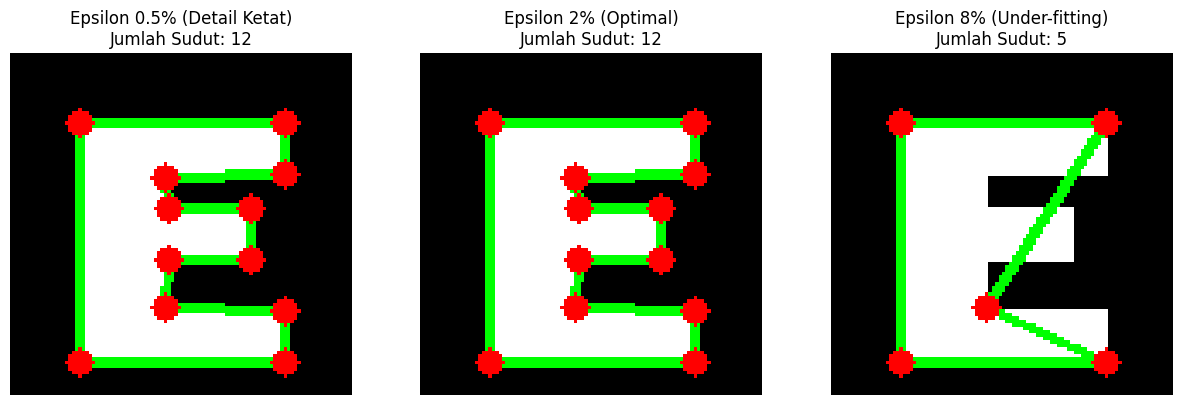

In [28]:
contours, _ = cv2.findContours(img_e, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = contours[0]
perimeter = cv2.arcLength(cnt, True)

# Eksperimen dengan 3 variasi Epsilon
epsilons = [0.005 * perimeter, 0.02 * perimeter, 0.08 * perimeter]
titles = ["Epsilon 0.5% (Detail Ketat)", "Epsilon 2% (Optimal)", "Epsilon 8% (Under-fitting)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, eps in enumerate(epsilons):
    canvas = cv2.cvtColor(img_e, cv2.COLOR_GRAY2BGR)
    # Hitung aproksimasi poligon
    approx = cv2.approxPolyDP(cnt, eps, True)

    # Gambar Garis Poligon (Hijau)
    cv2.drawContours(canvas, [approx], -1, (0, 255, 0), 2)
    # Gambar Titik Sudut / Vertices (Merah)
    for point in approx:
        cv2.circle(canvas, tuple(point[0]), 4, (255, 0, 0), -1)

    axes[i].imshow(canvas)
    axes[i].set_title(f"{titles[i]}\nJumlah Sudut: {len(approx)}")
    axes[i].axis('off')

plt.show()

## BAGIAN 3: Fitur Tekstur Spasial & Statistik (LBP & GLCM)

1. **LBP (Local Binary Pattern):** Mengekstrak tekstur mikro berdasarkan kecenderungan lokal (apakah tetangga lebih terang/gelap dibanding pusat).
2. **GLCM (Gray-Level Co-occurrence Matrix):** Mengukur hubungan spasial makro antar tingkat keabuan piksel berdasarkan jarak dan sudut tertentu.

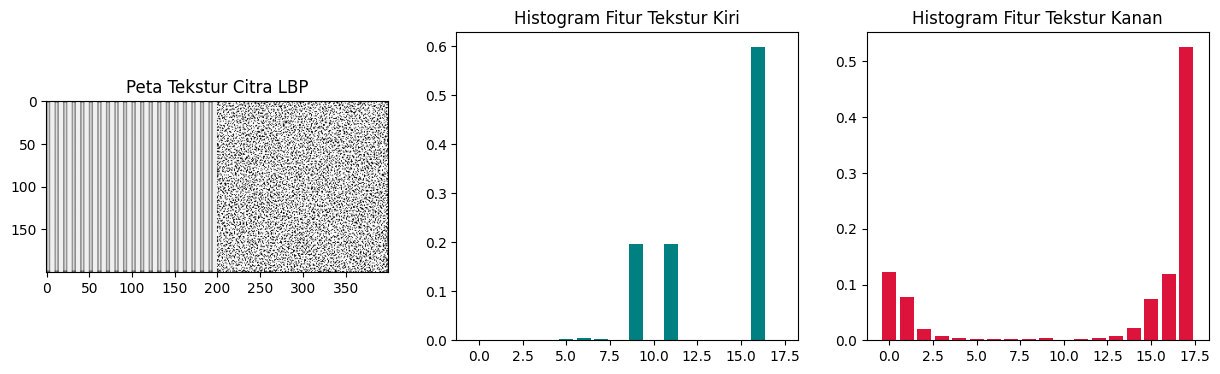

In [29]:
# 1. ANALISIS LOCAL BINARY PATTERN (LBP)
radius = 2
n_points = 8 * radius

# Ekstrak LBP dengan metode 'uniform' untuk menjamin invariansi rotasi dasar
lbp = local_binary_pattern(img_tex, n_points, radius, method='uniform')

# Belah hasil untuk komparasi tekstur Kiri (Garis Halus) vs Kanan (Grit Kasar)
lbp_kiri = lbp[:, :200]
lbp_kanan = lbp[:, 200:]

n_bins = int(lbp.max() + 1)
hist_kiri, _ = np.histogram(lbp_kiri.ravel(), bins=n_bins, range=(0, n_bins), density=True)
hist_kanan, _ = np.histogram(lbp_kanan.ravel(), bins=n_bins, range=(0, n_bins), density=True)

# Visualisasi LBP
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(lbp, cmap='gray'); axes[0].set_title("Peta Tekstur Citra LBP")
axes[1].bar(np.arange(n_bins), hist_kiri, color='teal'); axes[1].set_title("Histogram Fitur Tekstur Kiri")
axes[2].bar(np.arange(n_bins), hist_kanan, color='crimson'); axes[2].set_title("Histogram Fitur Tekstur Kanan")
plt.show()

In [30]:
# 2. ANALISIS GLCM (GRAY-LEVEL CO-OCCURRENCE MATRIX)
# Kita ambil sampel sub-citra patch ukuran 100x100 dari wilayah kiri dan kanan
patch_kiri = img_tex[50:150, 50:150]
patch_kanan = img_tex[50:150, 250:350]

# Hitung matriks ko-okurensi (Jarak=1 piksel, Sudut=0 derajat)
glcm_k = graycomatrix(patch_kiri, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
glcm_kn = graycomatrix(patch_kanan, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

# Ekstrak descriptor statistik dari GLCM
properties = ['contrast', 'homogeneity', 'energy', 'correlation']

print(f"{'Properti GLCM':<15} | {'Wilayah Kiri (Garis)':<20} | {'Wilayah Kanan (Noise)':<20}")
print("-" * 65)
for prop in properties:
    val_k = graycoprops(glcm_k, prop)[0, 0]
    val_kn = graycoprops(glcm_kn, prop)[0, 0]
    print(f"{prop.capitalize():<15} | {val_k:<20.5f} | {val_kn:<20.5f}")

Properti GLCM   | Wilayah Kiri (Garis) | Wilayah Kanan (Noise)
-----------------------------------------------------------------
Contrast        | 6218.18182           | 3210.91101          
Homogeneity     | 0.80809              | 0.02300             
Energy          | 0.58729              | 0.00999             
Correlation     | 0.61616              | 0.00441             


## BAGIAN 4: Harris Corner Detection

Harris Corner mendeteksi sudut menggunakan perubahan intensitas gradien lokal melalui matriks struktur tensor.
Sudut dicirikan oleh nilai *Eigenvalue* yang besar pada kedua arah ($\lambda_1$ dan $\lambda_2$).

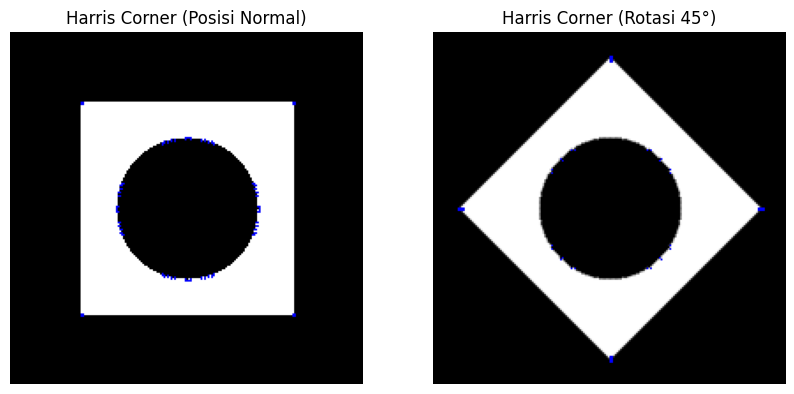

In [31]:
# Ubah data ke tipe float32 (wajib untuk fungsi harris)
gray_geo = np.float32(img_geo)

# Eksekusi Harris Corner
# Parameter: blockSize=2 (jendela integrasi), ksize=3 (Sobel apertur), k=0.04 (konstanta empiris)
harris_response = cv2.cornerHarris(gray_geo, 2, 3, 0.04)

# Lakukan rotasi 45 derajat pada gambar untuk menguji sifat 'Rotation Invariant'
rows, cols = img_geo.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
img_geo_rot = cv2.warpAffine(img_geo, M, (cols, rows))

gray_geo_rot = np.float32(img_geo_rot)
harris_response_rot = cv2.cornerHarris(gray_geo_rot, 2, 3, 0.04)

# Visualisasi deteksi sudut pada citra asli vs citra terotasi
canvas_normal = cv2.cvtColor(img_geo, cv2.COLOR_GRAY2BGR)
canvas_rot = cv2.cvtColor(img_geo_rot, cv2.COLOR_GRAY2BGR)

# Tandai area sudut yang kuat dengan warna merah murni
canvas_normal[harris_response > 0.01 * harris_response.max()] = [255, 0, 0]
canvas_rot[harris_response_rot > 0.01 * harris_response_rot.max()] = [255, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(canvas_normal, cv2.COLOR_BGR2RGB)); axes[0].set_title("Harris Corner (Posisi Normal)")
axes[1].imshow(cv2.cvtColor(canvas_rot, cv2.COLOR_BGR2RGB)); axes[1].set_title("Harris Corner (Rotasi 45°)")
for ax in axes: ax.axis('off')
plt.show()

## TUGAS MANDIRI / EVALUASI PRAKTIKUM (Kumpulkan Laporan)

1. **Analisis Chain Code:** Berdasarkan kode pada Bagian 1, lakukan rotasi 45 derajat pada `img_e` menggunakan fungsi `cv2.warpAffine`. Ekstrak kembali *Absolute Chain Code* dan *Differential Chain Code*-nya. Buktikan secara analisis data apakah benar *Differential Chain Code* bernilai sama (Invarian) pasca rotasi!
2. **Analisis Parameter GLCM:** Ubah parameter arah sudut (`angles=[0]`) pada fungsi `graycomatrix` di Bagian 3 menjadi 90 derajat (`angles=[np.pi/2]`). Amati perubahan nilai properti `Contrast` dan `Correlation` pada wilayah Kiri (Garis vertikal). Jelaskan mengapa nilainya berubah drastis berdasarkan perubahan sudut penyisiran tersebut!

<h2> Tugas 1 Analisis Chain </h2>
<p>Berdasarkan kode pada Bagian 1, lakukan rotasi 45 derajat pada img_e menggunakan fungsi cv2.warpAffine. Ekstrak kembali Absolute Chain Code dan Differential Chain Code-nya. Buktikan secara analisis data apakah benar Differential Chain Code bernilai sama (Invarian) pasca rotasi!</p>

<h4>Sebelum Rotasi 45 Derajat</h4>

In [41]:
# Eksekusi Fungsi
abs_code, diff_code = extract_freeman_chain_code(img_e)

print(f"--- ANALISIS BENTUK HURUF E ---")
print(f"Total Piksel Batas Keliling : {len(abs_code)}")
print(f"Absolute Chain Code (100 sampel pertama):\n{abs_code[:100]}\n")
print(f"Differential Chain Code (100 sampel pertama):\n{diff_code[:100]}")

--- ANALISIS BENTUK HURUF E ---
Total Piksel Batas Keliling : 376
Absolute Chain Code (100 sampel pertama):
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Differential Chain Code (100 sampel pertama):
[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


<h4>Sesudah Rotasi 45 Derajat</h4>

In [43]:
# Rotasi 45 derajat pada gambar IMG E
rows, cols = img_e.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
img_e_rotasi = cv2.warpAffine(img_e, M, (cols, rows))

# Eksekusi Fungsi
abs_code_r, diff_code_r = extract_freeman_chain_code(img_e_rotasi)

print(f"--- ANALISIS BENTUK HURUF E ---")
print(f"Total Piksel Batas Keliling : {len(abs_code_r)}")
print(f"Absolute Chain Code (100 sampel pertama):\n{abs_code_r[:100]}\n")
print(f"Differential Chain Code (100 sampel pertama):\n{diff_code_r[:100]}")

--- ANALISIS BENTUK HURUF E ---
Total Piksel Batas Keliling : 270
Absolute Chain Code (100 sampel pertama):
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 0, 1, 1, 1, 1, 1, 1]

Differential Chain Code (100 sampel pertama):
[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]


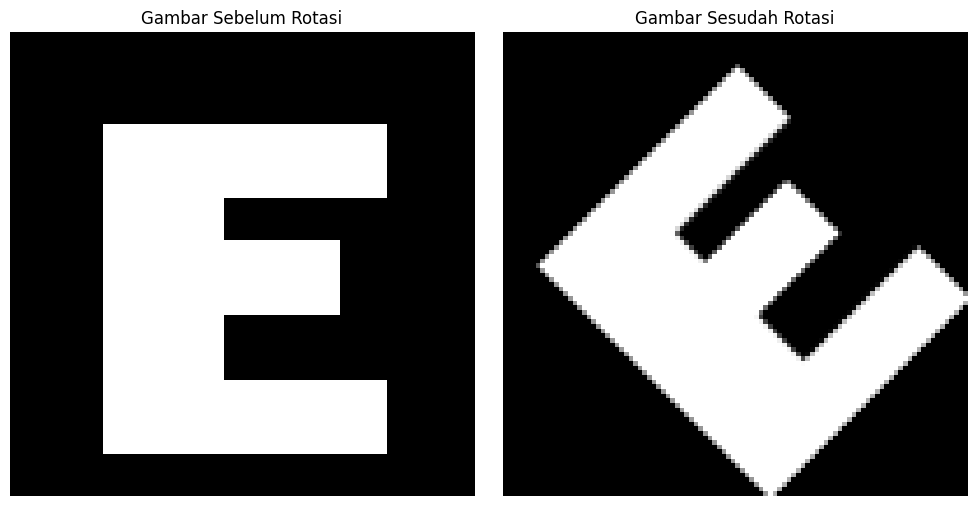

In [34]:
# Visualisasi Gambar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_e, cmap='gray')
axes[0].set_title("Gambar Sebelum Rotasi")
axes[0].axis('off')
axes[1].imshow(img_e_rotasi, cmap='gray')
axes[1].set_title("Gambar Sesudah Rotasi")
axes[1].axis('off')
plt.tight_layout()
plt.savefig('tuga1_chaincode_rotasi.png')
plt.show()

In [44]:
print(f'=== HASIL ANALISIS CHAIN CODE ===')
print(f'Sebelum Rotasi: ')
print(f'Total Piksel Batas Keliling : {len(abs_code)}')
print(f"Absolute Chain Code (100 sampel pertama):\n{abs_code[:100]}\n")
print(f"Differential Chain Code (100 sampel pertama):\n{diff_code[:100]}")
print(f'Sesudah Rotasi: ')
print(f'Total Piksel Batas Keliling : {len(abs_code_r)}')
print(f"Absolute Chain Code (100 sampel pertama):\n{abs_code_r[:100]}\n")
print(f"Differential Chain Code (100 sampel pertama):\n{diff_code_r[:100]}")

=== HASIL ANALISIS CHAIN CODE ===
Sebelum Rotasi: 
Total Piksel Batas Keliling : 376
Absolute Chain Code (100 sampel pertama):
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Differential Chain Code (100 sampel pertama):
[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sesudah Rotasi: 
Total Piksel Batas Keliling : 270
Absolute Chain Code (100 sampel pertama):
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7

<h1>Tugas 2 Analisis Parameter GLCM</h1>
<p>Ubah parameter arah sudut (angles=[0]) pada fungsi graycomatrix di Bagian 3 menjadi 90 derajat (angles=[np.pi/2]). Amati perubahan nilai properti Contrast dan Correlation pada wilayah Kiri (Garis vertikal). Jelaskan mengapa nilainya berubah drastis berdasarkan perubahan sudut penyisiran tersebut!</p>

In [45]:
# 2. ANALISIS GLCM (GRAY-LEVEL CO-OCCURRENCE MATRIX)
# Kita ambil sampel sub-citra patch ukuran 100x100 dari wilayah kiri dan kanan
patch_kiri = img_tex[50:150, 50:150]
patch_kanan = img_tex[50:150, 250:350]

# Hitung matriks ko-okurensi (Jarak=1 piksel, Sudut=0 derajat)
glcm_k = graycomatrix(patch_kiri, distances=[1], angles=[np.pi/2], levels=256, symmetric=True, normed=True)
glcm_kn = graycomatrix(patch_kanan, distances=[1], angles=[np.pi/2], levels=256, symmetric=True, normed=True)

# Ekstrak descriptor statistik dari GLCM
properties = ['contrast', 'homogeneity', 'energy', 'correlation']

print(f"{'Properti GLCM':<15} | {'Wilayah Kiri (Garis)':<20} | {'Wilayah Kanan (Noise)':<20}")
print("-" * 65)
for prop in properties:
    val_k = graycoprops(glcm_k, prop)[0, 0]
    val_kn = graycoprops(glcm_kn, prop)[0, 0]
    print(f"{prop.capitalize():<15} | {val_k:<20.5f} | {val_kn:<20.5f}")

Properti GLCM   | Wilayah Kiri (Garis) | Wilayah Kanan (Noise)
-----------------------------------------------------------------
Contrast        | 0.00000              | 3234.03606          
Homogeneity     | 1.00000              | 0.02072             
Energy          | 0.70711              | 0.01006             
Correlation     | 1.00000              | -0.00194            


<h1>Hasil Analisis GLCM (Sudut 90°)</h1>

<ol>
  <li><strong>Contrast (0.00000):</strong> Tidak ada variasi intensitas piksel karena jalur pemindaian vertikal searah dengan bentangan garis (hanya mendeteksi putih-putih atau hitam-hitam).</li>
  <li><strong>Homogeneity (1.00000):</strong> Pola tekstur sangat seragam secara vertikal karena tidak ada interupsi batas tepi antara marka jalan dan aspal.</li>
  <li><strong>Energy (0.70711):</strong> Tingkat keteraturan pola tinggi dan tidak acak, didominasi hanya oleh kombinasi pasangan piksel yang homogen (terpusat).</li>
  <li><strong>Correlation (1.00000):</strong> Hubungan linear antar piksel spasial sempurna; jika suatu piksel berwarna putih, maka piksel di bawahnya pasti putih.</li>
</ol>